## Project - Fifa20 

Project Goal: The goal of this project is to analyze the Fifa20players dataset and cluster them based on their attributes to gain a better understanding of their playing styles and contributions to the game.

### Task 1 : Prepare a complete data analysis report on the given data.

#### Import Basic Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

### Loading data 

In [2]:
data = pd.read_csv("D:\Projects\Fifa20\players_20.csv")
data.head()

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,32,1987-06-24,170,72,Argentina,FC Barcelona,...,68+2,66+2,66+2,66+2,68+2,63+2,52+2,52+2,52+2,63+2
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,34,1985-02-05,187,83,Portugal,Juventus,...,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3
2,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Junior,27,1992-02-05,175,68,Brazil,Paris Saint-Germain,...,66+3,61+3,61+3,61+3,66+3,61+3,46+3,46+3,46+3,61+3
3,200389,https://sofifa.com/player/200389/jan-oblak/20/...,J. Oblak,Jan Oblak,26,1993-01-07,188,87,Slovenia,Atlético Madrid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,183277,https://sofifa.com/player/183277/eden-hazard/2...,E. Hazard,Eden Hazard,28,1991-01-07,175,74,Belgium,Real Madrid,...,66+3,63+3,63+3,63+3,66+3,61+3,49+3,49+3,49+3,61+3


### Basic checks

In [3]:
data.sample(10)

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
15792,197974,https://sofifa.com/player/197974/adam-dawson/2...,A. Dawson,Adam Dawson,26,1992-10-05,175,78,England,Macclesfield Town,...,46+2,42+2,42+2,42+2,46+2,44+2,36+2,36+2,36+2,44+2
7812,235338,https://sofifa.com/player/235338/marlon-rodrig...,Marlon,Marlon Rodrigues Xavier,22,1997-05-20,173,68,Brazil,Boavista FC,...,67+2,63+2,63+2,63+2,67+2,66+2,62+2,62+2,62+2,66+2
11503,202528,https://sofifa.com/player/202528/josh-ruffels/...,J. Ruffels,Josh Ruffels,25,1993-10-23,178,75,England,Oxford United,...,63+2,65+2,65+2,65+2,63+2,62+2,63+2,63+2,63+2,62+2
6956,247696,https://sofifa.com/player/247696/ahmed-barman/...,A. Barman,Ahmed Barman,25,1994-02-05,175,72,United Arab Emirates,Al Ain FC,...,64+2,66+2,66+2,66+2,64+2,64+2,65+2,65+2,65+2,64+2
11099,243510,https://sofifa.com/player/243510/ognjen-stijep...,O. Stijepović,Ognjen Stijepović,19,1999-10-22,185,74,Montenegro,Sampdoria,...,51+2,50+2,50+2,50+2,51+2,49+2,44+2,44+2,44+2,49+2
14331,235205,https://sofifa.com/player/235205/bright-gyamfi...,B. Gyamfi,Bright Gyamfi,23,1996-01-20,178,76,Ghana,Benevento,...,58+2,54+2,54+2,54+2,58+2,59+2,59+2,59+2,59+2,59+2
2255,207616,https://sofifa.com/player/207616/adam-webster/...,A. Webster,Adam Webster,24,1995-01-04,191,75,England,Brighton & Hove Albion,...,66+2,69+2,69+2,69+2,66+2,67+2,72+2,72+2,72+2,67+2
12652,225714,https://sofifa.com/player/225714/federico-anse...,F. Anselmo,Federico Anselmo,25,1994-06-11,188,86,Argentina,Independiente Santa Fe,...,37+2,37+2,37+2,37+2,37+2,36+2,38+2,38+2,38+2,36+2
4559,192091,https://sofifa.com/player/192091/welinton-souz...,Welinton,Welinton Souza Silva,30,1989-04-10,181,81,Brazil,Alanyaspor,...,62+2,65+2,65+2,65+2,62+2,64+2,70+2,70+2,70+2,64+2
17546,235715,https://sofifa.com/player/235715/harry-paton/2...,H. Paton,Harry Paton,21,1998-05-23,175,70,Canada,Ross County FC,...,52+2,53+2,53+2,53+2,52+2,52+2,54+2,54+2,54+2,52+2


In [4]:
data.tail()

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
18273,245006,https://sofifa.com/player/245006/shuai-shao/20...,Shao Shuai,邵帅,22,1997-03-10,186,79,China PR,Beijing Renhe FC,...,43+2,42+2,42+2,42+2,43+2,45+2,46+2,46+2,46+2,45+2
18274,250995,https://sofifa.com/player/250995/mingjie-xiao/...,Xiao Mingjie,Mingjie Xiao,22,1997-01-01,177,66,China PR,Shanghai SIPG FC,...,44+2,43+2,43+2,43+2,44+2,46+2,47+2,47+2,47+2,46+2
18275,252332,https://sofifa.com/player/252332/wei-zhang/20/...,Zhang Wei,张威,19,2000-05-16,186,75,China PR,Hebei China Fortune FC,...,47+2,49+2,49+2,49+2,47+2,47+2,49+2,49+2,49+2,47+2
18276,251110,https://sofifa.com/player/251110/haijian-wang/...,Wang Haijian,汪海健,18,2000-08-02,185,74,China PR,Shanghai Greenland Shenhua FC,...,48+2,48+2,48+2,48+2,48+2,48+2,49+2,49+2,49+2,48+2
18277,233449,https://sofifa.com/player/233449/ximing-pan/20...,Pan Ximing,潘喜明,26,1993-01-11,182,78,China PR,Hebei China Fortune FC,...,48+2,49+2,49+2,49+2,48+2,48+2,50+2,50+2,50+2,48+2


In [5]:
data.head

<bound method NDFrame.head of        sofifa_id                                         player_url  \
0         158023  https://sofifa.com/player/158023/lionel-messi/...   
1          20801  https://sofifa.com/player/20801/c-ronaldo-dos-...   
2         190871  https://sofifa.com/player/190871/neymar-da-sil...   
3         200389  https://sofifa.com/player/200389/jan-oblak/20/...   
4         183277  https://sofifa.com/player/183277/eden-hazard/2...   
...          ...                                                ...   
18273     245006  https://sofifa.com/player/245006/shuai-shao/20...   
18274     250995  https://sofifa.com/player/250995/mingjie-xiao/...   
18275     252332  https://sofifa.com/player/252332/wei-zhang/20/...   
18276     251110  https://sofifa.com/player/251110/haijian-wang/...   
18277     233449  https://sofifa.com/player/233449/ximing-pan/20...   

              short_name                            long_name  age  \
0               L. Messi       Lionel Andrés Me

In [6]:
data.dtypes

sofifa_id     int64
player_url      str
short_name      str
long_name       str
age           int64
              ...  
lb              str
lcb             str
cb              str
rcb             str
rb              str
Length: 104, dtype: object

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 18278 entries, 0 to 18277
Columns: 104 entries, sofifa_id to rb
dtypes: float64(16), int64(45), str(43)
memory usage: 14.5 MB


In [8]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
sofifa_id,18278.0,219738.864482,27960.200461,768.0,204445.5,226165.0,240795.75,252905.0
age,18278.0,25.283291,4.656964,16.0,22.0,25.0,29.00,42.0
height_cm,18278.0,181.362184,6.756961,156.0,177.0,181.0,186.00,205.0
weight_kg,18278.0,75.276343,7.047744,50.0,70.0,75.0,80.00,110.0
overall,18278.0,66.244994,6.949953,48.0,62.0,66.0,71.00,94.0
...,...,...,...,...,...,...,...,...
goalkeeping_diving,18278.0,16.572765,17.738069,1.0,8.0,11.0,14.00,90.0
goalkeeping_handling,18278.0,16.354853,16.996925,1.0,8.0,11.0,14.00,92.0
goalkeeping_kicking,18278.0,16.212934,16.613665,1.0,8.0,11.0,14.00,93.0
goalkeeping_positioning,18278.0,16.368038,17.136497,1.0,8.0,11.0,14.00,91.0


In [9]:
columns = list(data.columns)
print(columns)

['sofifa_id', 'player_url', 'short_name', 'long_name', 'age', 'dob', 'height_cm', 'weight_kg', 'nationality', 'club', 'overall', 'potential', 'value_eur', 'wage_eur', 'player_positions', 'preferred_foot', 'international_reputation', 'weak_foot', 'skill_moves', 'work_rate', 'body_type', 'real_face', 'release_clause_eur', 'player_tags', 'team_position', 'team_jersey_number', 'loaned_from', 'joined', 'contract_valid_until', 'nation_position', 'nation_jersey_number', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'gk_diving', 'gk_handling', 'gk_kicking', 'gk_reflexes', 'gk_speed', 'gk_positioning', 'player_traits', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movement_balance', 'power_shot_power', 'power_

In [10]:
data.shape

(18278, 104)

## Examine the data

In [11]:
data.info() # If view all feature use verbose=True

<class 'pandas.DataFrame'>
RangeIndex: 18278 entries, 0 to 18277
Columns: 104 entries, sofifa_id to rb
dtypes: float64(16), int64(45), str(43)
memory usage: 14.5 MB


## Statistical measure of data

In [12]:
data.describe()

,sofifa_id,age,height_cm,weight_kg,overall,potential,value_eur,wage_eur,international_reputation,weak_foot,...,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
count,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,1.827800e+04,18278.000000,18278.000000,18278.000000,...,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000
mean,219738.864482,25.283291,181.362184,75.276343,66.244994,71.546887,2.484038e+06,9456.942773,1.103184,2.944250,...,48.383357,58.528778,46.848889,47.640333,45.606631,16.572765,16.354853,16.212934,16.368038,16.709924
std,27960.200461,4.656964,6.756961,7.047744,6.949953,6.139669,5.585481e+06,21351.714095,0.378861,0.664656,...,15.708099,11.880840,20.091287,21.585641,21.217734,17.738069,16.996925,16.613665,17.136497,18.038125
min,768.000000,16.000000,156.000000,50.000000,48.000000,49.000000,0.000000e+00,0.000000,1.000000,1.000000,...,7.000000,12.000000,1.000000,5.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,204445.500000,22.000000,177.000000,70.000000,62.000000,67.000000,3.250000e+05,1000.000000,1.000000,3.000000,...,39.000000,51.000000,29.000000,27.000000,24.000000,8.000000,8.000000,8.000000,8.000000,8.000000
50%,226165.000000,25.000000,181.000000,75.000000,66.000000,71.000000,7.000000e+05,3000.000000,1.000000,3.000000,...,49.000000,60.000000,52.000000,55.000000,52.000000,11.000000,11.000000,11.000000,11.000000,11.000000
75%,240795.750000,29.000000,186.000000,80.000000,71.000000,75.000000,2.100000e+06,8000.000000,1.000000,3.000000,...,60.000000,67.000000,64.000000,66.000000,64.000000,14.000000,14.000000,14.000000,14.000000,14.000000
max,252905.000000,42.000000,205.000000,110.000000,94.000000,95.000000,1.055000e+08,565000.000000,5.000000,5.000000,...,92.000000,96.000000,94.000000,92.000000,90.000000,90.000000,92.000000,93.000000,91.000000,92.000000


In [13]:
data.describe(include='O')

,player_url,short_name,long_name,dob,nationality,club,player_positions,preferred_foot,work_rate,body_type,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
count,18278,18278,18278,18278,18278,18278,18278,18278,18278,18278,...,16242,16242,16242,16242,16242,16242,16242,16242,16242,16242
unique,18278,17354,18218,6142,162,698,643,2,9,10,...,98,98,98,98,98,96,110,110,110,96
top,https://sofifa.com/player/158023/lionel-messi/...,J. Rodríguez,Liam Kelly,1992-02-29,England,FC Barcelona,CB,Right,Medium/Medium,Normal,...,59+2,59+2,59+2,59+2,59+2,61+2,63+2,63+2,63+2,61+2
freq,1,11,3,113,1667,33,2322,13960,9875,10750,...,682,636,636,636,682,667,621,621,621,667


In [14]:
data.describe(include='O')

,player_url,short_name,long_name,dob,nationality,club,player_positions,preferred_foot,work_rate,body_type,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
count,18278,18278,18278,18278,18278,18278,18278,18278,18278,18278,...,16242,16242,16242,16242,16242,16242,16242,16242,16242,16242
unique,18278,17354,18218,6142,162,698,643,2,9,10,...,98,98,98,98,98,96,110,110,110,96
top,https://sofifa.com/player/158023/lionel-messi/...,J. Rodríguez,Liam Kelly,1992-02-29,England,FC Barcelona,CB,Right,Medium/Medium,Normal,...,59+2,59+2,59+2,59+2,59+2,61+2,63+2,63+2,63+2,61+2
freq,1,11,3,113,1667,33,2322,13960,9875,10750,...,682,636,636,636,682,667,621,621,621,667


### Explotary data analysis (EDA) is a process of analyzing and investigating data sets to summarize their main characteristics, often with visual methods. 
### It is an important step in the data science process, as it helps to identify patterns, relationships, and anomalies in the data that can inform further analysis and modeling.

### Remove the special character and split the string

* Because it creating issue to do analysis

In [15]:
# first remove the special character from data 
data = data.replace('[\#]','', regex=True)
data.head(1)

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,32,1987-06-24,170,72,Argentina,FC Barcelona,...,68+2,66+2,66+2,66+2,68+2,63+2,52+2,52+2,52+2,63+2


In [16]:
# Split the columnand remove the '+' with the values after them
columns = ['ls', 'st', 'rs', 'lw', 'lf', 'cf', 'rf', 'rw', 'lam', 'cam', 'ram', 'lm', 'lcm', 'cm', 'rcm', 'rm', 'lwb', 'ldm', 'cdm', 'rdm', 'rwb','lb','lcb','cb','rcb','rb']
data[columns]

for column in columns: # for itertion of columns
    data[column] = data[column].str.split('+',expand=True)[0] # split of string
data.head(1)

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,32,1987-06-24,170,72,Argentina,FC Barcelona,...,68,66,66,66,68,63,52,52,52,63


# Exploratory Data Analysis

## 1)Univariate Analysis 

In [17]:
univariate = data[[ 'age',  'height_cm', 'weight_kg','overall', 'potential', 'value_eur', 'wage_eur', 
                   'preferred_foot', 'international_reputation', 'weak_foot', 'skill_moves', 'work_rate', 'body_type',
                   'real_face', 'release_clause_eur', 'player_tags', 'team_position', 'team_jersey_number', 
                   'contract_valid_until', 'nation_position', 'nation_jersey_number', 'pace', 'shooting', 'passing',
                   'dribbling', 'defending', 'physic', 'gk_diving', 'gk_handling', 'gk_kicking', 'gk_reflexes', 'gk_speed', 
                   'gk_positioning','attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy',
                   'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 
                   'skill_long_passing', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 
                   'movement_agility', 'movement_reactions', 'movement_balance', 'power_shot_power', 'power_jumping', 
                   'power_stamina', 'power_strength', 'power_long_shots', 'mentality_aggression', 'mentality_interceptions',
                   'mentality_positioning', 'mentality_vision', 'mentality_penalties', 'mentality_composure', 'defending_marking',
                   'defending_standing_tackle', 'defending_sliding_tackle', 'goalkeeping_diving', 'goalkeeping_handling', 
                   'goalkeeping_kicking', 'goalkeeping_positioning', 'goalkeeping_reflexes', 'ls', 'st', 'rs', 'lw', 'lf', 
                   'cf', 'rf', 'rw', 'lam','cam', 'ram', 'lm', 'lcm', 'cm', 'rcm', 'rm', 'lwb', 'ldm', 'cdm', 'rdm', 'rwb',
                   'lb', 'lcb', 'cb', 'rcb', 'rb']]
import sweetviz
sv = sweetviz.analyze(univariate)


                                             |          | [  0%]   00:00 -> (? left)

findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight nor

## 2)Bivariate and Multivariate Analysis
### Numerical veriable
#### 1)Impact of AGE to Movement Reaction

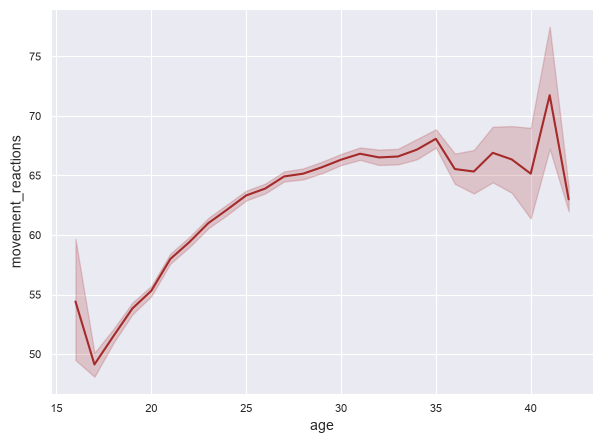

In [18]:
plt.figure(figsize=(7,5))
sns.set_style('darkgrid')
sns.lineplot(x='age',y='movement_reactions',data=data,color='brown')
plt.show()

### Observation:
- At the age 15 to 20 movement reaction is less.
- if player age is increasing player movement reaction also increasing.

## 2) Imact of height to weight

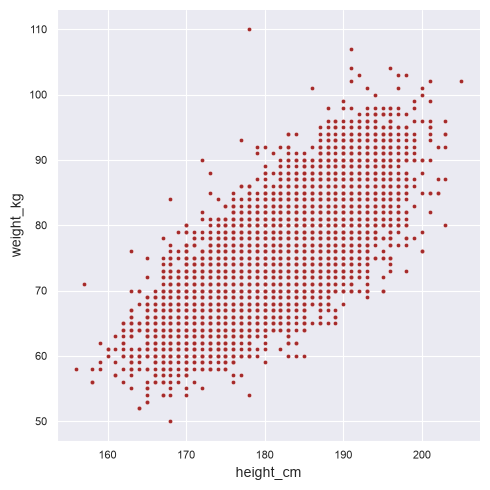

In [19]:
sns.relplot(x='height_cm',y='weight_kg',data=data,color='brown')
plt.show()

## Observation:
- if the players hight is increases player weight also increases.
### 3) Relation between overall and potential with  respect to preferred foot

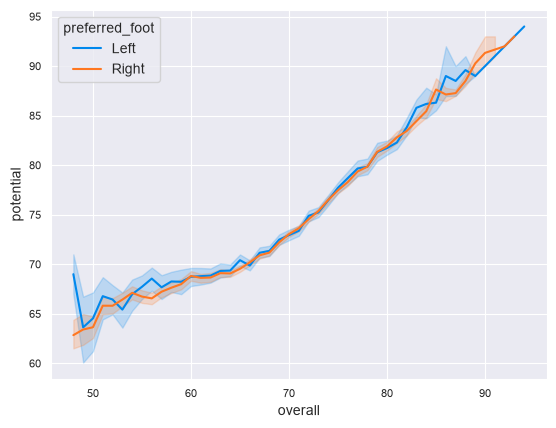

In [20]:
sns.lineplot(x='overall',y='potential',data=data,color='brown',hue='preferred_foot')
plt.show()

## Observation:
- if players overall score is increasing the score of potential also increasing with both foot.
### 4) relationship between valueeur and wage euro with respect to preferred foot

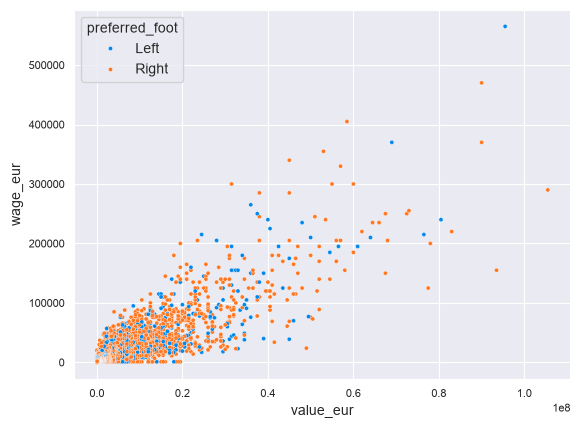

In [21]:
sns.scatterplot(x='value_eur',y='wage_eur',data=data,color='brown',hue='preferred_foot')
plt.show()

## Observation:
- if player value is less then the wage of player also less.
- if the value of player is more the wage is siglightly more.
### 5)Impact of contract valid until to release clause eur

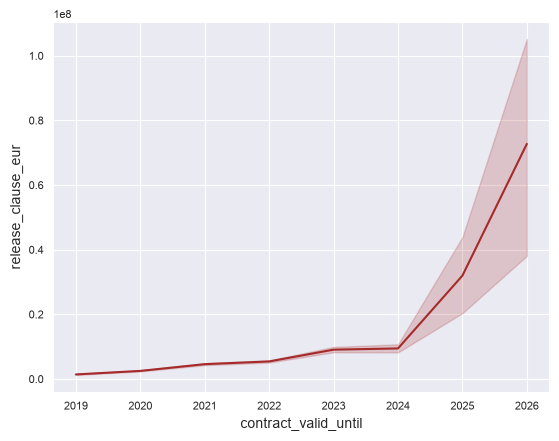

In [22]:
sns.lineplot(x='contract_valid_until',y='release_clause_eur',data=data,color='brown')
plt.show()

## Observation:
- if player contract until 2024 to 2026 then the clause of player is more.
- if player contract valid unitl 2019 to 2024 then the release clause of player is less.
### 6) Relation between pace and shooting with respect to preferred foot

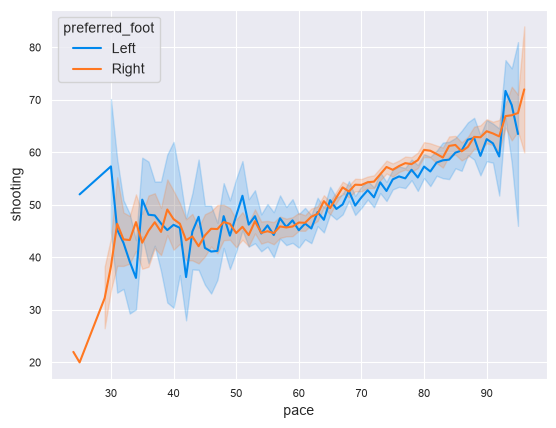

In [23]:
sns.lineplot(x='pace',y='shooting',data=data,color='brown',hue='preferred_foot')
plt.show()

## Observation:
- If the player preferref left foot then the pace is less but shooting is around 50 to 60.
- if the player preferred right foot then the pace is less as well as shooting also less.
### 7)Impact of dribbling to defending

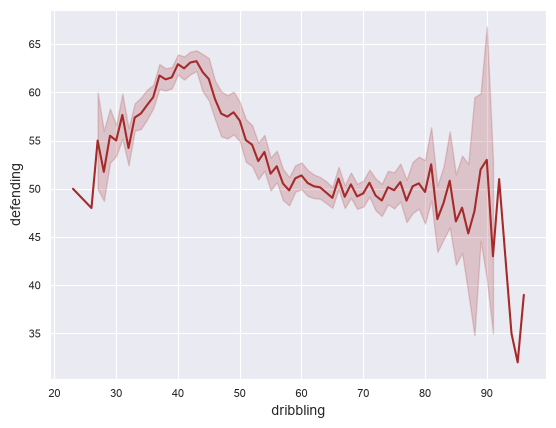

In [24]:
sns.lineplot(x='dribbling',y='defending',data=data,color='brown')
plt.show()

## Observation:
- if the dribbling score is 30 to 50 then the defending score is high.
- if dribbling score is more then the defending score also less.
### 8)Impact of physic to attacking crossing

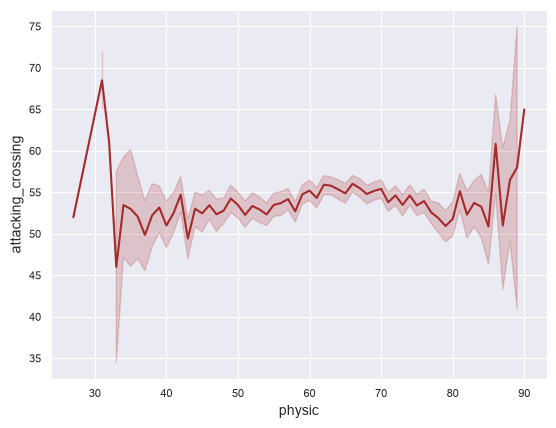

In [25]:
sns.lineplot(x='physic',y='attacking_crossing',data=data,color='brown')
plt.show()

## Observation:
- if the physic is less then the attacking crossing is more.
- Otherwise physic range between 35 to 80 the attacking crossing is constant.
### 9) Impact of GK diving to GK handling

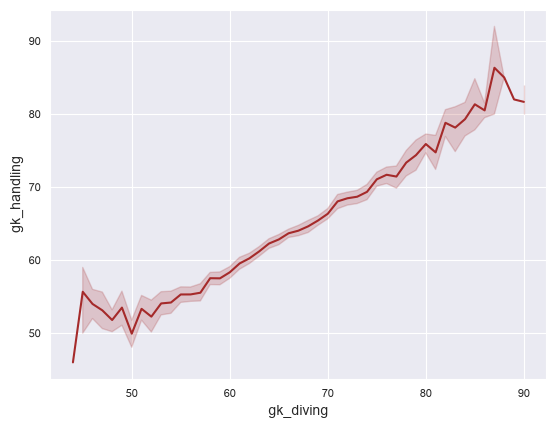

In [26]:
sns.lineplot(x='gk_diving',y='gk_handling',data=data,color='brown')
plt.show()

## Observation:
- if the gk diving score is increases the gk handling score also increases.
### 10) Impact of GK relexs to GK speed

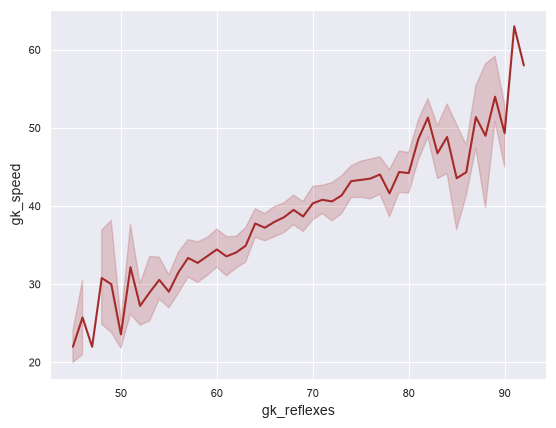

In [27]:
sns.lineplot(x='gk_reflexes',y='gk_speed',data=data,color='brown')
plt.show()

## Observation:
- Less gk reflexes then the gk speed also less.
- More gk reflexes then the gk speed alo more.
### 11) Impact of GK positioning to GK kicking

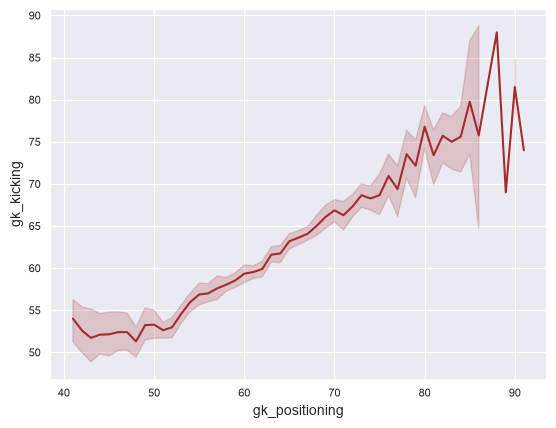

In [28]:
sns.lineplot(x='gk_positioning',y='gk_kicking',data=data,color='brown')
plt.show()

## Observation:
- If the gk position score is less then the gk kicking score also less.
- If the gk positioning score is increases then the gk kicking score also increases.
### 12) Impact of attacking crossing to attacking finishing.

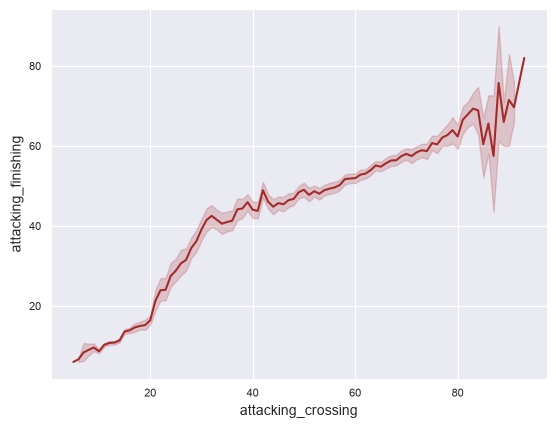

In [29]:
sns.lineplot(x='attacking_crossing',y='attacking_finishing',data=data,color='brown')
plt.show()

## Observation:
- Attcking score between 20 to 40 then attacking finishing score around 40to 50.
- Either attacking crossing is more then attacking finshing also more.
### 13)Impact of attacking short passing to attacking volleys

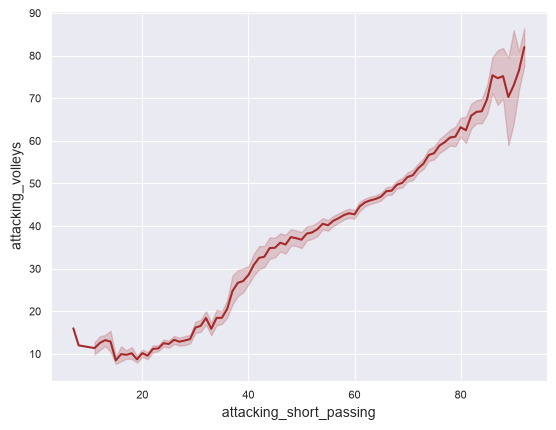

In [30]:
sns.lineplot(x='attacking_short_passing',y='attacking_volleys',data=data,color='brown')
plt.show()

## Observation:
- More attacking short passing then the more attacking vollyes.
- Less attacking short passing then the less attacking volleys.
### 14) Impact of skill dribbling to skill ball control.

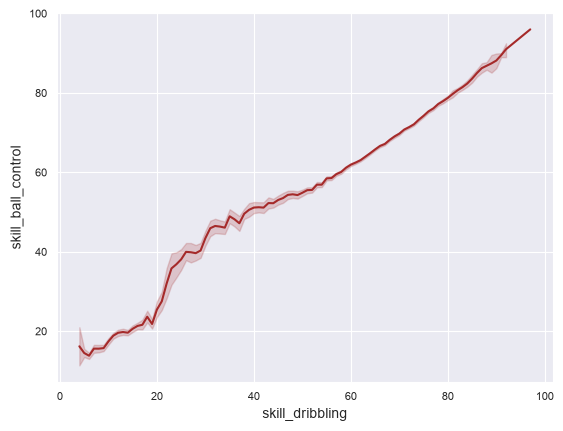

In [31]:
sns.lineplot(x='skill_dribbling',y='skill_ball_control',data=data,color='brown')
plt.show()

## OBSERVATION:
- If the dribbling skill is more then ball control skill also more.
### 15..RELATION BETWEEN SKILL CURVE AND SKILL FK ACCURACY WITH RESPECT TO PREFERRED FOOT

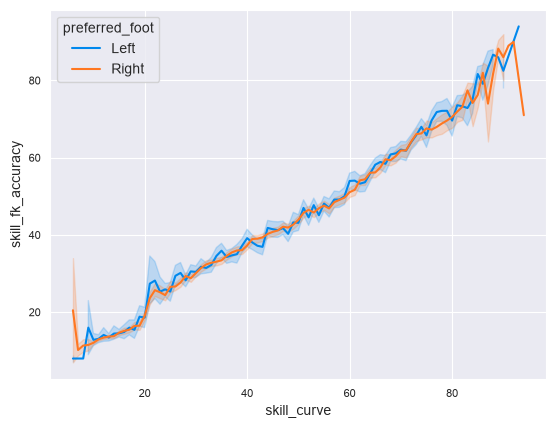

In [32]:
sns.lineplot(x='skill_curve',y='skill_fk_accuracy',data=data,color='brown',hue='preferred_foot')
plt.show()

## Observation:
- If skill curve is increases then the skill fk accuracy is also increases with both foot.
### 16)Impact of skill long passing to power long shots.

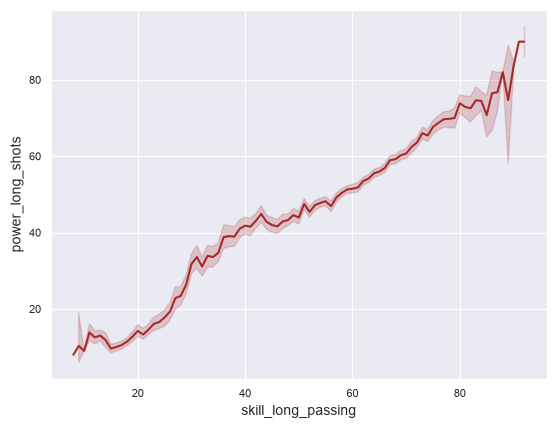

In [33]:
sns.lineplot(x='skill_long_passing',y='power_long_shots',data=data,color='brown')
plt.show()

## OBSERVATION:
- More skills of long passing then the increase of power long shots.
### 17.IMPACT OF MOVEMENT SPRINT SPEED TO MOVEMENT REACTION

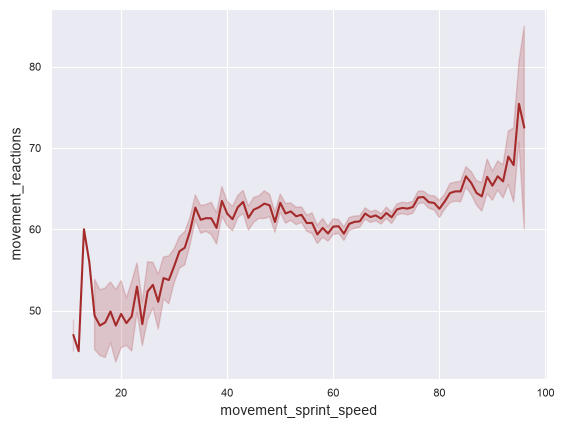

In [34]:
sns.lineplot(x='movement_sprint_speed',y='movement_reactions',data=data,color='brown')
plt.show()

## OBSERVATION:
-Movement sprint range around 40 to 100 then the movement reaction is constant otherwise fall in both
### 18.IMPACT OF POWER SHOT TO POWER STAMINA

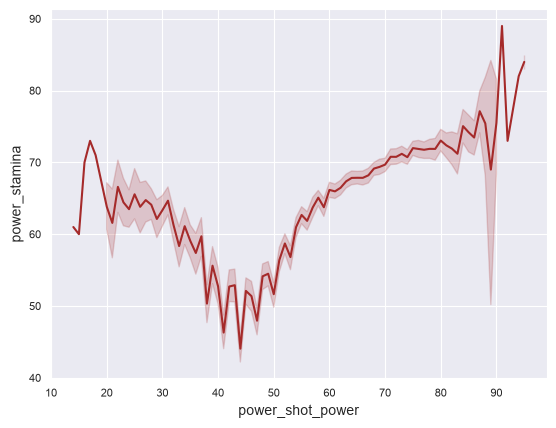

In [35]:
sns.lineplot(x='power_shot_power',y='power_stamina',data=data,color='brown')
plt.show()

## OBSERVATION:
- If the power shot range around 30 to 60 then the power stamina is decreases
- If the player has more shot power then the stamina is more.
### 19.IMPACT OF POWER JUMPING TO POWER STRENGTH

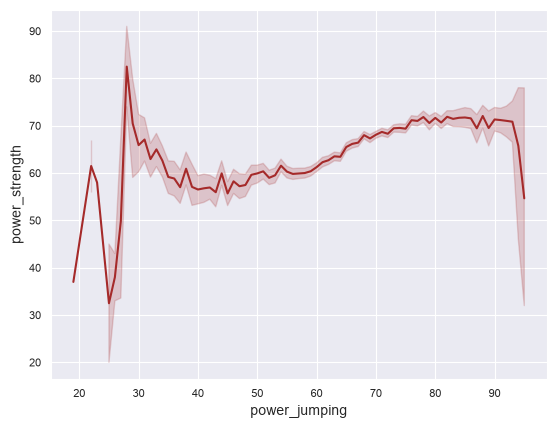

In [36]:
sns.lineplot(x='power_jumping',y='power_strength',data=data,color='brown')
plt.show()

## OBSERVATION:
- If the power jumping is 30 then the power strength is more and below 30 power jumping less power strength.
- Power jumping above 30 then the power strength is constant
### 20.IMPACT TO MENTALITY AGGRESSION TO MENTALITY POSITIONING

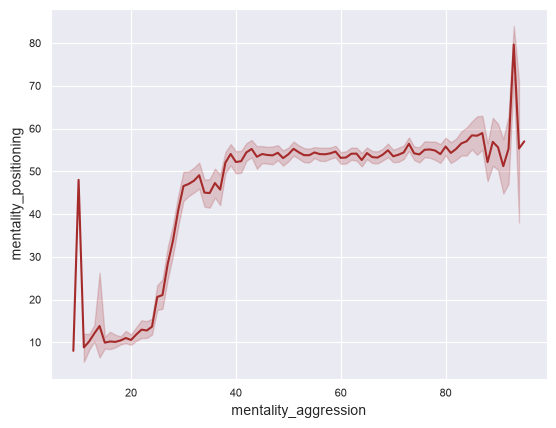

In [37]:
sns.lineplot(x='mentality_aggression',y='mentality_positioning',data=data,color='brown')
plt.show()

## OBSERVATION:
- If the mentality aggression around 10 to 30 then the mentality positioning is low
- Below 10 mentality aggression the score of mentality positioning is slightly high. otherwise both metality positioning score is constant.
### 21.IMPACT OF MENTALITY PENALTIES TO MENTALITY VISION

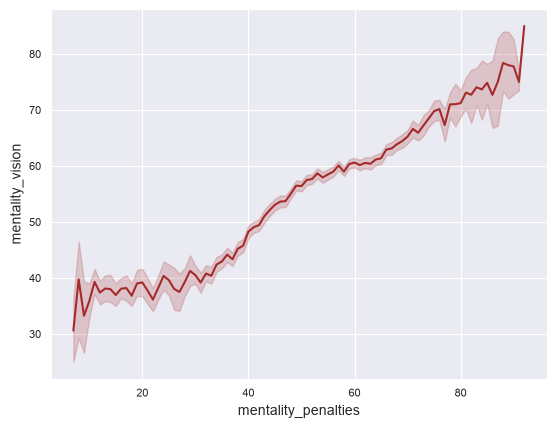

In [38]:
sns.lineplot(x='mentality_penalties',y='mentality_vision',data=data,color='brown')
plt.show()

## OBSERVATION:
- If the penalties is increases then the mentality vision also increases.
### 22.RELATION BETWEEN DEFENDING STANDING TACKLE & DEFENDING SLIDING TACKLE WITH RESPECT TO PREFERRED FOOT

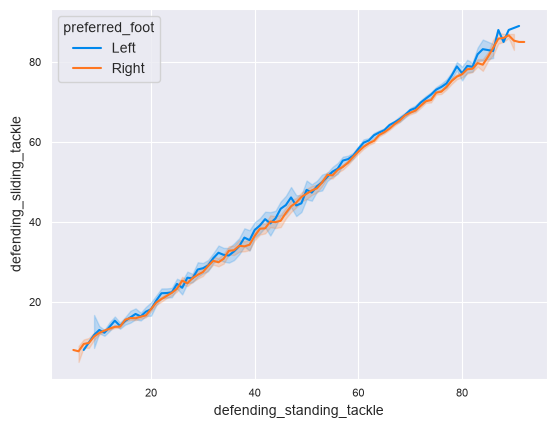

In [39]:
sns.lineplot(x='defending_standing_tackle',y='defending_sliding_tackle',data=data,color='brown',hue='preferred_foot')
plt.show()

## OBSERVATION:
- If defending standing tackle is increases then the defending sliding tackle also increases with both foot.
## CATEGORICAL VERIABLE
### 1.IMPACT OF INTERNATIONAL REPUTATION TO WEAK FOOT

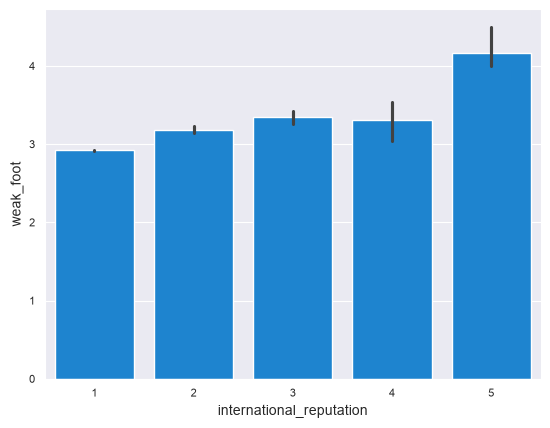

In [40]:
sns.barplot(x='international_reputation',y='weak_foot',data=data)
plt.show()

## OBSERVATION:
- 5 Intrenational reputation rating of player has more than 4 week foot
- 1 international reputation rating player has less than 3 weak foot
- 2, 3, 4 international reputation player has constant weak foot
### 2.impact of work rate to skill moves

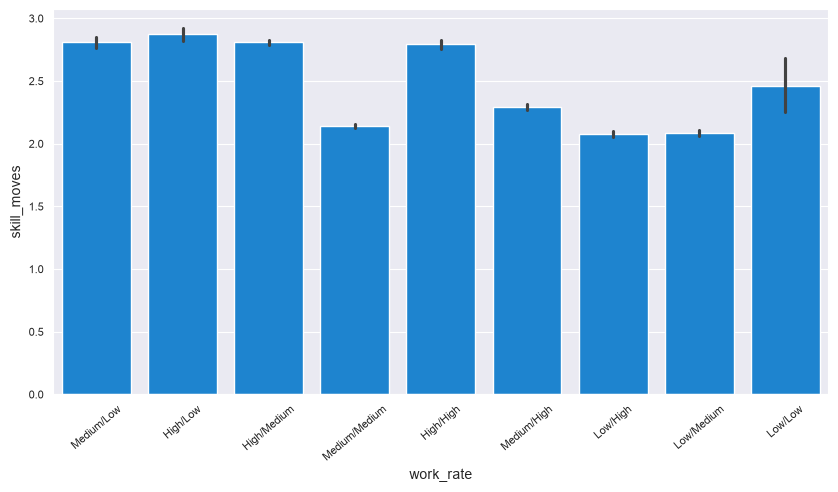

In [41]:
plt .figure(figsize=(10,5))
sns.barplot(x='work_rate',y='skill_moves',data=data)
plt.xticks(rotation=40)
plt.show()

## OBSERVATION:
- In this plot cleary seen that 4 types of work rate[medium/low, high/low, high/medium, high/high] has more than 2.5 skill moves
- Other work rate skill moves is less than 2.5
### 3.Impact of real face to release clause eur

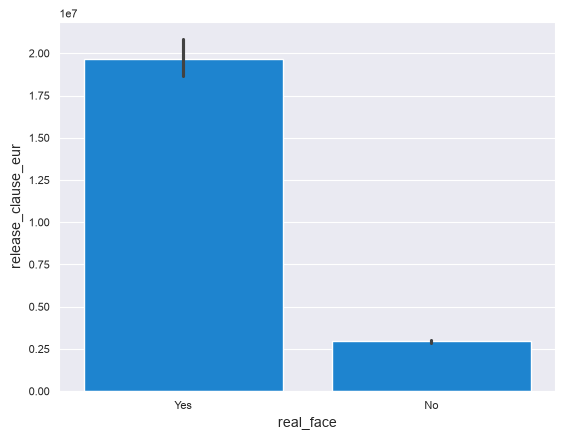

In [42]:
sns.barplot(x='real_face',y='release_clause_eur',data=data)
plt.show()

# Task 3: Exploring specific questions on FIFA 20 Players dataset

We will explore the data to answer the following three questions:
1. Prepare a rank ordered list of top 10 countries with most players.
2. Plot the distribution of overall rating vs. age of players. Interpret what is the age after which a player stops improving.
3. Which type of offensive players tends to get paid the most: the striker, the right-winger, or the left-winger?

Top 10 countries with most players:
nationality
England        1667
Germany        1216
Spain          1035
France          984
Argentina       886
Brazil          824
Italy           732
Colombia        591
Japan           453
Netherlands     416
Name: count, dtype: int64


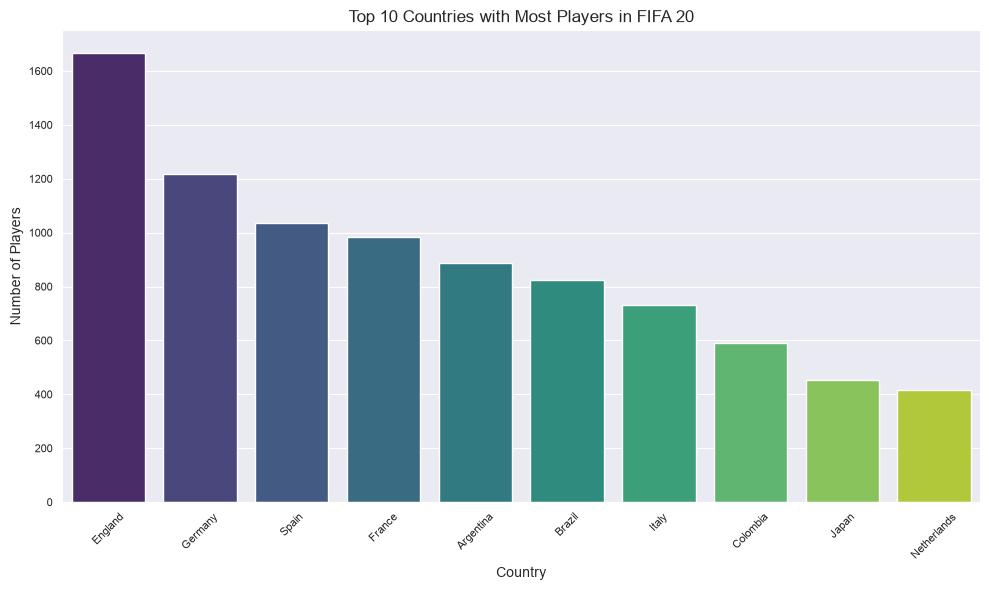

In [43]:
# Question 1: Top 10 countries with most players
top_10_countries = data['nationality'].value_counts().head(10)
print("Top 10 countries with most players:")
print(top_10_countries)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_countries.index, y=top_10_countries.values, palette='viridis')
plt.title('Top 10 Countries with Most Players in FIFA 20')
plt.xlabel('Country')
plt.ylabel('Number of Players')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation:
- **England** produces the highest number of players (1,667), followed by **Germany** (1,216), **Spain** (1,035), and **France** (984).
- European and South American countries dominate the list, reflecting the deep footballing culture, infrastructure, and academies in these regions that produce players at the top professional level.

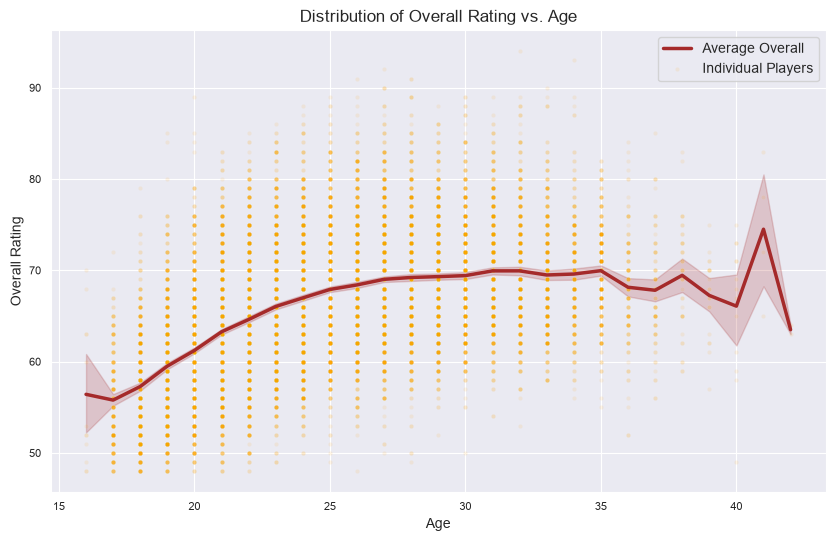

Average Overall Rating by Age:
age
16    56.416667
17    55.786026
18    57.273438
19    59.507418
20    61.222133
21    63.262545
22    64.609959
23    66.038292
24    66.977623
25    67.904473
26    68.400787
27    69.013595
28    69.216390
29    69.308308
30    69.420159
31    69.938042
32    69.941374
33    69.488421
34    69.591362
35    69.961290
36    68.145038
37    67.814815
38    69.452381
39    67.250000
40    66.076923
41    74.500000
42    63.500000
Name: overall, dtype: float64


In [44]:
# Question 2: Overall rating vs. Age of players
plt.figure(figsize=(10, 6))
sns.lineplot(x='age', y='overall', data=data, color='brown', linewidth=2.5, label='Average Overall')
sns.scatterplot(x='age', y='overall', data=data, color='orange', alpha=0.1, label='Individual Players')
plt.title('Distribution of Overall Rating vs. Age')
plt.xlabel('Age')
plt.ylabel('Overall Rating')
plt.legend()
plt.show()

# Average overall by age
age_overall_mean = data.groupby('age')['overall'].mean()
print("Average Overall Rating by Age:")
print(age_overall_mean)

### Observation:
- The overall rating rises steeply for young players (ages 16 to 25), indicating rapid improvement and development.
- The overall rating plateaus between the ages of **28 and 32** (peaking around 69.9).
- After **age 32**, the average overall rating begins to decline as players begin to age and experience physical decline (especially speed, agility, and stamina).
- Therefore, **31 to 32** is the age after which a player generally stops improving.

Wages Comparison:
                      Mean Wage  Median Wage
Striker (ST)       10612.288786       4000.0
Right Winger (RW)  13625.766871       4000.0
Left Winger (LW)   14541.284404       4000.0


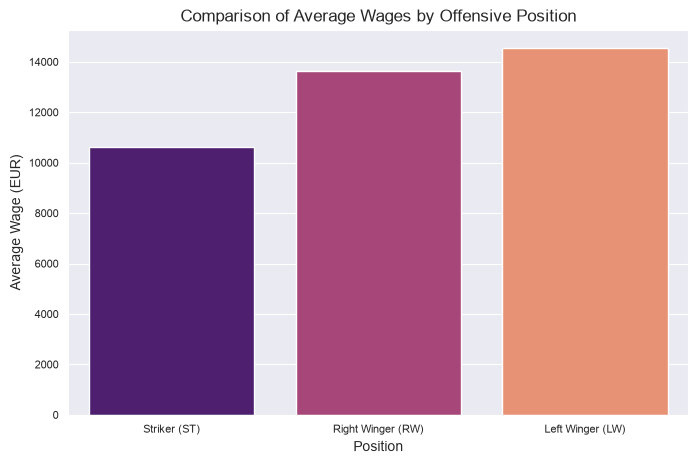

In [45]:
# Question 3: Wages of Striker (ST), Right Winger (RW), Left Winger (LW)
is_st = data['player_positions'].apply(lambda x: any(pos.strip() == 'ST' for pos in str(x).split(',')))
is_rw = data['player_positions'].apply(lambda x: any(pos.strip() == 'RW' for pos in str(x).split(',')))
is_lw = data['player_positions'].apply(lambda x: any(pos.strip() == 'LW' for pos in str(x).split(',')))

st_wages = data[is_st]['wage_eur'].dropna()
rw_wages = data[is_rw]['wage_eur'].dropna()
lw_wages = data[is_lw]['wage_eur'].dropna()

wages_df = pd.DataFrame({
    'Striker (ST)': [st_wages.mean(), st_wages.median()],
    'Right Winger (RW)': [rw_wages.mean(), rw_wages.median()],
    'Left Winger (LW)': [lw_wages.mean(), lw_wages.median()]
}, index=['Mean Wage', 'Median Wage']).T

print("Wages Comparison:")
print(wages_df)

plt.figure(figsize=(8, 5))
sns.barplot(x=wages_df.index, y='Mean Wage', data=wages_df, palette='magma')
plt.title('Comparison of Average Wages by Offensive Position')
plt.ylabel('Average Wage (EUR)')
plt.xlabel('Position')
plt.show()

### Observation:
- **Left-wingers (LW)** tend to get paid the highest average wage (~14,541 EUR), followed closely by **Right-wingers (RW)** (~13,626 EUR).
- **Strikers (ST)** earn significantly less on average (~10,612 EUR).
- This indicates that wingers tend to command higher wages, which aligns with modern football tactical demands where explosive, creative wingers are highly valued and hard to find.

# Task 2: Explore football skills and cluster players based on their attributes

We will perform clustering on players based on their detailed skillset to group them into playing styles.

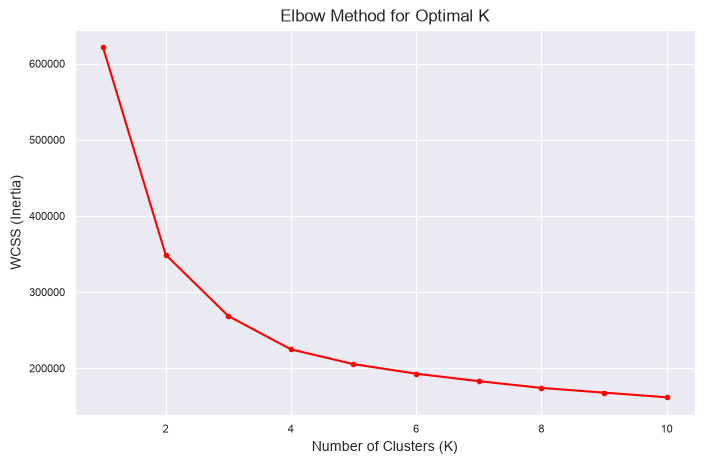

In [46]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Select 34 detailed skill columns
skill_cols = [
    'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys',
    'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control',
    'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movement_balance',
    'power_shot_power', 'power_jumping', 'power_stamina', 'power_strength', 'power_long_shots',
    'mentality_aggression', 'mentality_interceptions', 'mentality_positioning', 'mentality_vision', 'mentality_penalties', 'mentality_composure',
    'defending_marking', 'defending_standing_tackle', 'defending_sliding_tackle',
    'goalkeeping_diving', 'goalkeeping_handling', 'goalkeeping_kicking', 'goalkeeping_positioning', 'goalkeeping_reflexes'
]

# Ensure no missing values in skill columns
X = data[skill_cols].fillna(0)

# Scale the attributes
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Run KMeans with K ranging from 1 to 10 for the Elbow Curve
wcss = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, 'ro-')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

In [47]:
# Fit KMeans with optimal K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
data['cluster'] = kmeans.fit_predict(X_scaled)
print("Player counts in each cluster:")
print(data['cluster'].value_counts())

# Display profiling statistics
profile_attrs = ['attacking_finishing', 'defending_standing_tackle', 'goalkeeping_diving', 'movement_acceleration', 'skill_ball_control', 'power_strength', 'power_stamina']
profiles = data.groupby('cluster')[profile_attrs].mean()
print("\nCluster Profiles (Mean Values):")
print(profiles)

Player counts in each cluster:
cluster
0    5686
3    5311
2    5245
1    2036
Name: count, dtype: int64

Cluster Profiles (Mean Values):
         attacking_finishing  defending_standing_tackle  goalkeeping_diving  \
cluster                                                                       
0                  57.231622                  60.752550           10.610447   
1                  11.598723                  13.946464           65.422397   
2                  31.738799                  64.024976           10.386845   
3                  59.836942                  30.337978           10.338354   

         movement_acceleration  skill_ball_control  power_strength  \
cluster                                                              
0                    69.940028           70.943897       67.819381   
1                    37.688114           19.690079       60.483301   
2                    60.801335           54.690944       69.894757   
3                    71.918471       

### Cluster Interpretation:
Based on the average attributes and position analysis, the 4 clusters represent:
1. **Cluster 0: Playmakers & Midfielders (Box-to-Box)** - High stamina, ball control, and passing, with a good balance between attack and defense.
2. **Cluster 1: Goalkeepers** - Characterized by extremely high goalkeeping stats and near-zero outfield stats.
3. **Cluster 2: Defensive Specialists** - High strength and tackling ratings, with very low finishing and attacking statistics.
4. **Cluster 3: Attackers & Wingers** - High sprint speed, acceleration, dribbling, and finishing, with low defending ratings.

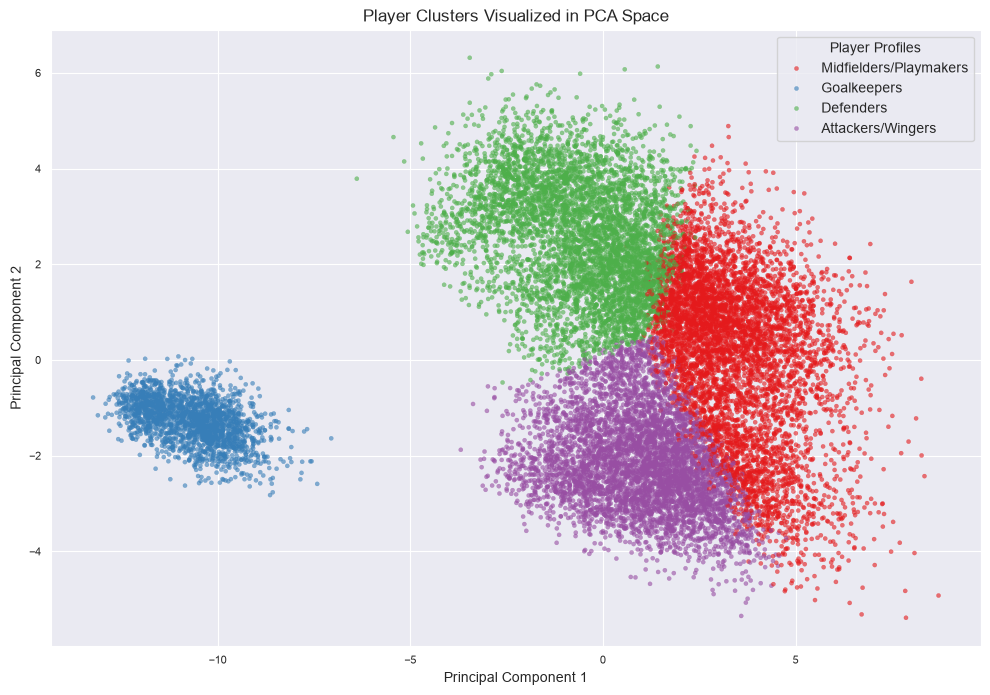

In [48]:
# Reduce to 2 dimensions using PCA for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
data['pca1'] = X_pca[:, 0]
data['pca2'] = X_pca[:, 1]

# Define custom label mapping for clusters
cluster_labels = {
    0: 'Midfielders/Playmakers',
    1: 'Goalkeepers',
    2: 'Defenders',
    3: 'Attackers/Wingers'
}
data['cluster_label'] = data['cluster'].map(cluster_labels)

# Scatter plot in PCA space
plt.figure(figsize=(12, 8))
sns.scatterplot(x='pca1', y='pca2', hue='cluster_label', data=data, palette='Set1', alpha=0.6, edgecolor=None)
plt.title('Player Clusters Visualized in PCA Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Player Profiles')
plt.grid(True)
plt.show()

# Conclusion and Key Takeaways

1. **Player Archetypes**: By using K-Means with K=4, players are naturally grouped into 4 distinct, tactically coherent clusters: Goalkeepers, Defenders, Midfielders/Playmakers, and Attackers/Wingers.
2. **Salary Trends**: Wingers (particularly LWs) are the most highly compensated offensive players in terms of average wages, while traditional strikers earn relatively less.
3. **Player Development**: Players improve their overall ratings rapidly until age 25, plateauing and peaking between ages 28 and 32. After age 32, overall ratings decrease on average, matching the physical decline seen in professional football.